# electricity load forecasting using LSTM
- this notebook provides the code for the section 5.1 of the following paper
- it is worth noting that the results and details of the model are provided in section 6.2

paper: https://www.researchgate.net/profile/Mojtaba-Mohammadi-11/publication/350237035_Stochastic_Energy_Management_and_Scheduling_of_Microgrids_in_Correlated_Environment_A_Deep_Learning-Oriented_approach/links/605e38ca92851cd8ce6c1697/Stochastic-Energy-Management-and-Scheduling-of-Microgrids-in-Correlated-Environment-A-Deep-Learning-Oriented-approach.pdf

In [138]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from pandas.plotting import register_matplotlib_converters
from keras.models import Sequential
from keras.layers import LSTM
import warnings
from sklearn.preprocessing import RobustScaler


warnings.filterwarnings(action='ignore')
%matplotlib inline
%config InlineBackend.figure_format='retina'

register_matplotlib_converters()
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 22, 10

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# model patameters
Dropout_rate = 0.3
batch_size = 32
time_steps = 14
no_epochs = 50
test_ratio = 0.2

- reading the data from the csv file

In [139]:

df = pd.read_csv(
  "malaysia_all_data_for_paper.csv", 
  parse_dates=['date'], 
  index_col="date"
)

- Extracting time indexes (hour, month, day of week, day od month, year) from the date column

In [140]:
# this section generates the data indexes
df['hour'] = df.index.hour
df['day_of_month'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

In [141]:
df.head

<bound method NDFrame.head of                      power  hour  day_of_month  day_of_week  month
date                                                              
2009-01-01 00:00:00  30360     0             1            3      1
2009-01-01 01:00:00  29155     1             1            3      1
2009-01-01 02:00:00  28086     2             1            3      1
2009-01-01 03:00:00  28031     3             1            3      1
2009-01-01 04:00:00  27730     4             1            3      1
...                    ...   ...           ...          ...    ...
2010-12-31 18:00:00  53819    18            31            4     12
2010-12-31 19:00:00  51543    19            31            4     12
2010-12-31 20:00:00  44961    20            31            4     12
2010-12-31 21:00:00  38484    21            31            4     12
2010-12-31 22:00:00  36729    22            31            4     12

[17519 rows x 5 columns]>

- plotting the active power values

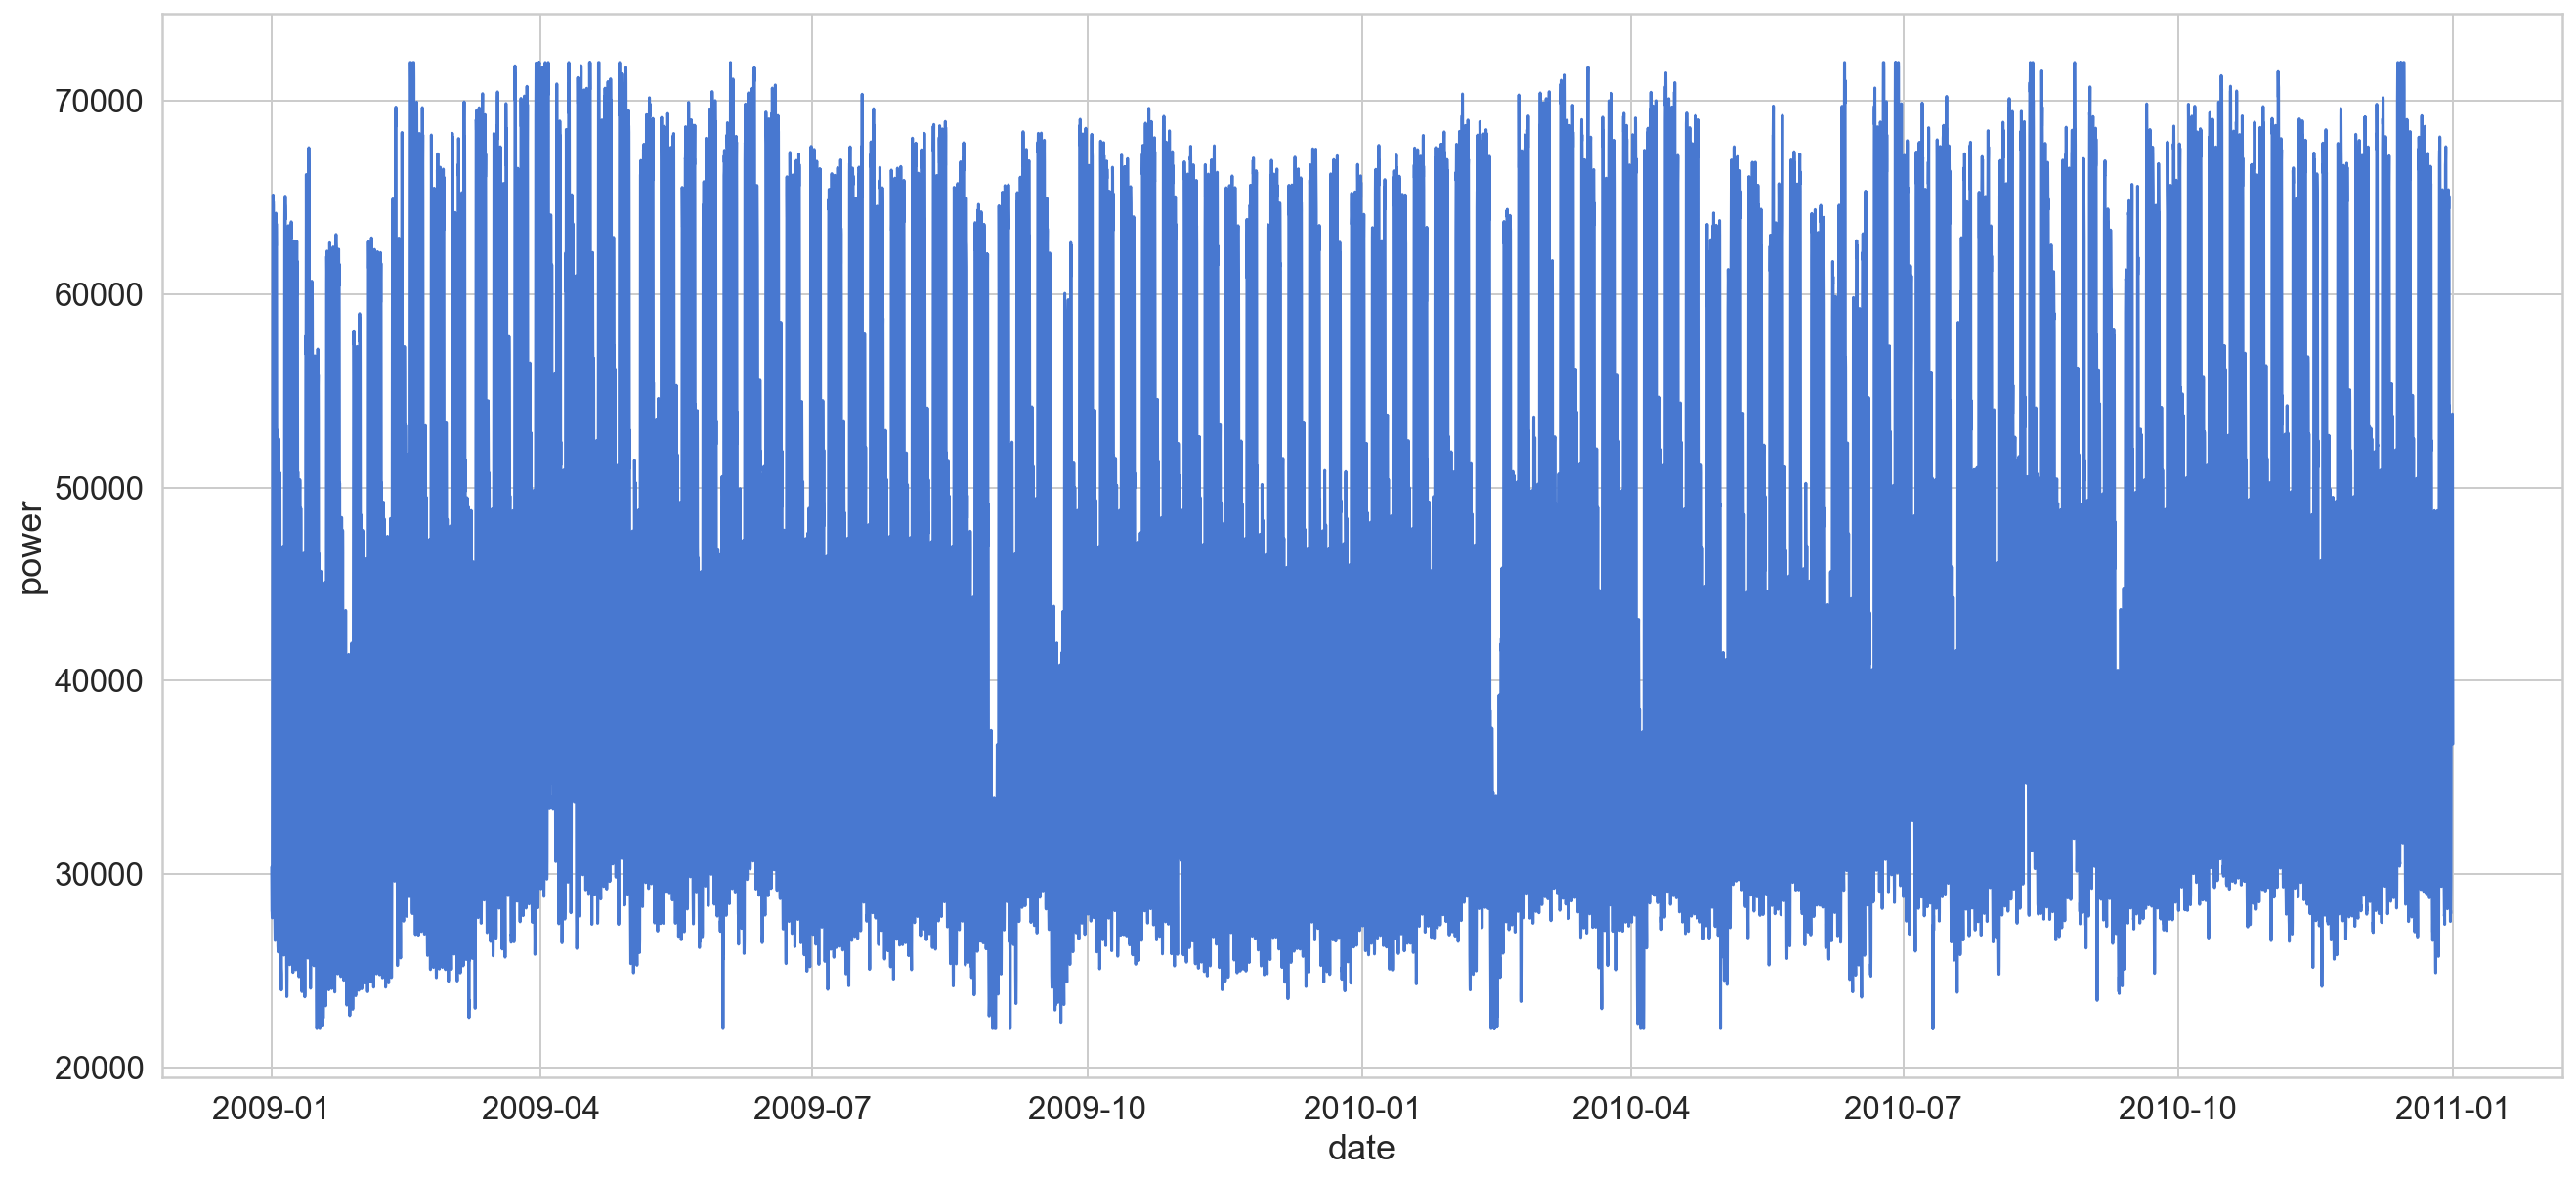

In [142]:
sns.lineplot(x=df.index, y="power", data=df);

- Some data visualization for understanding the data

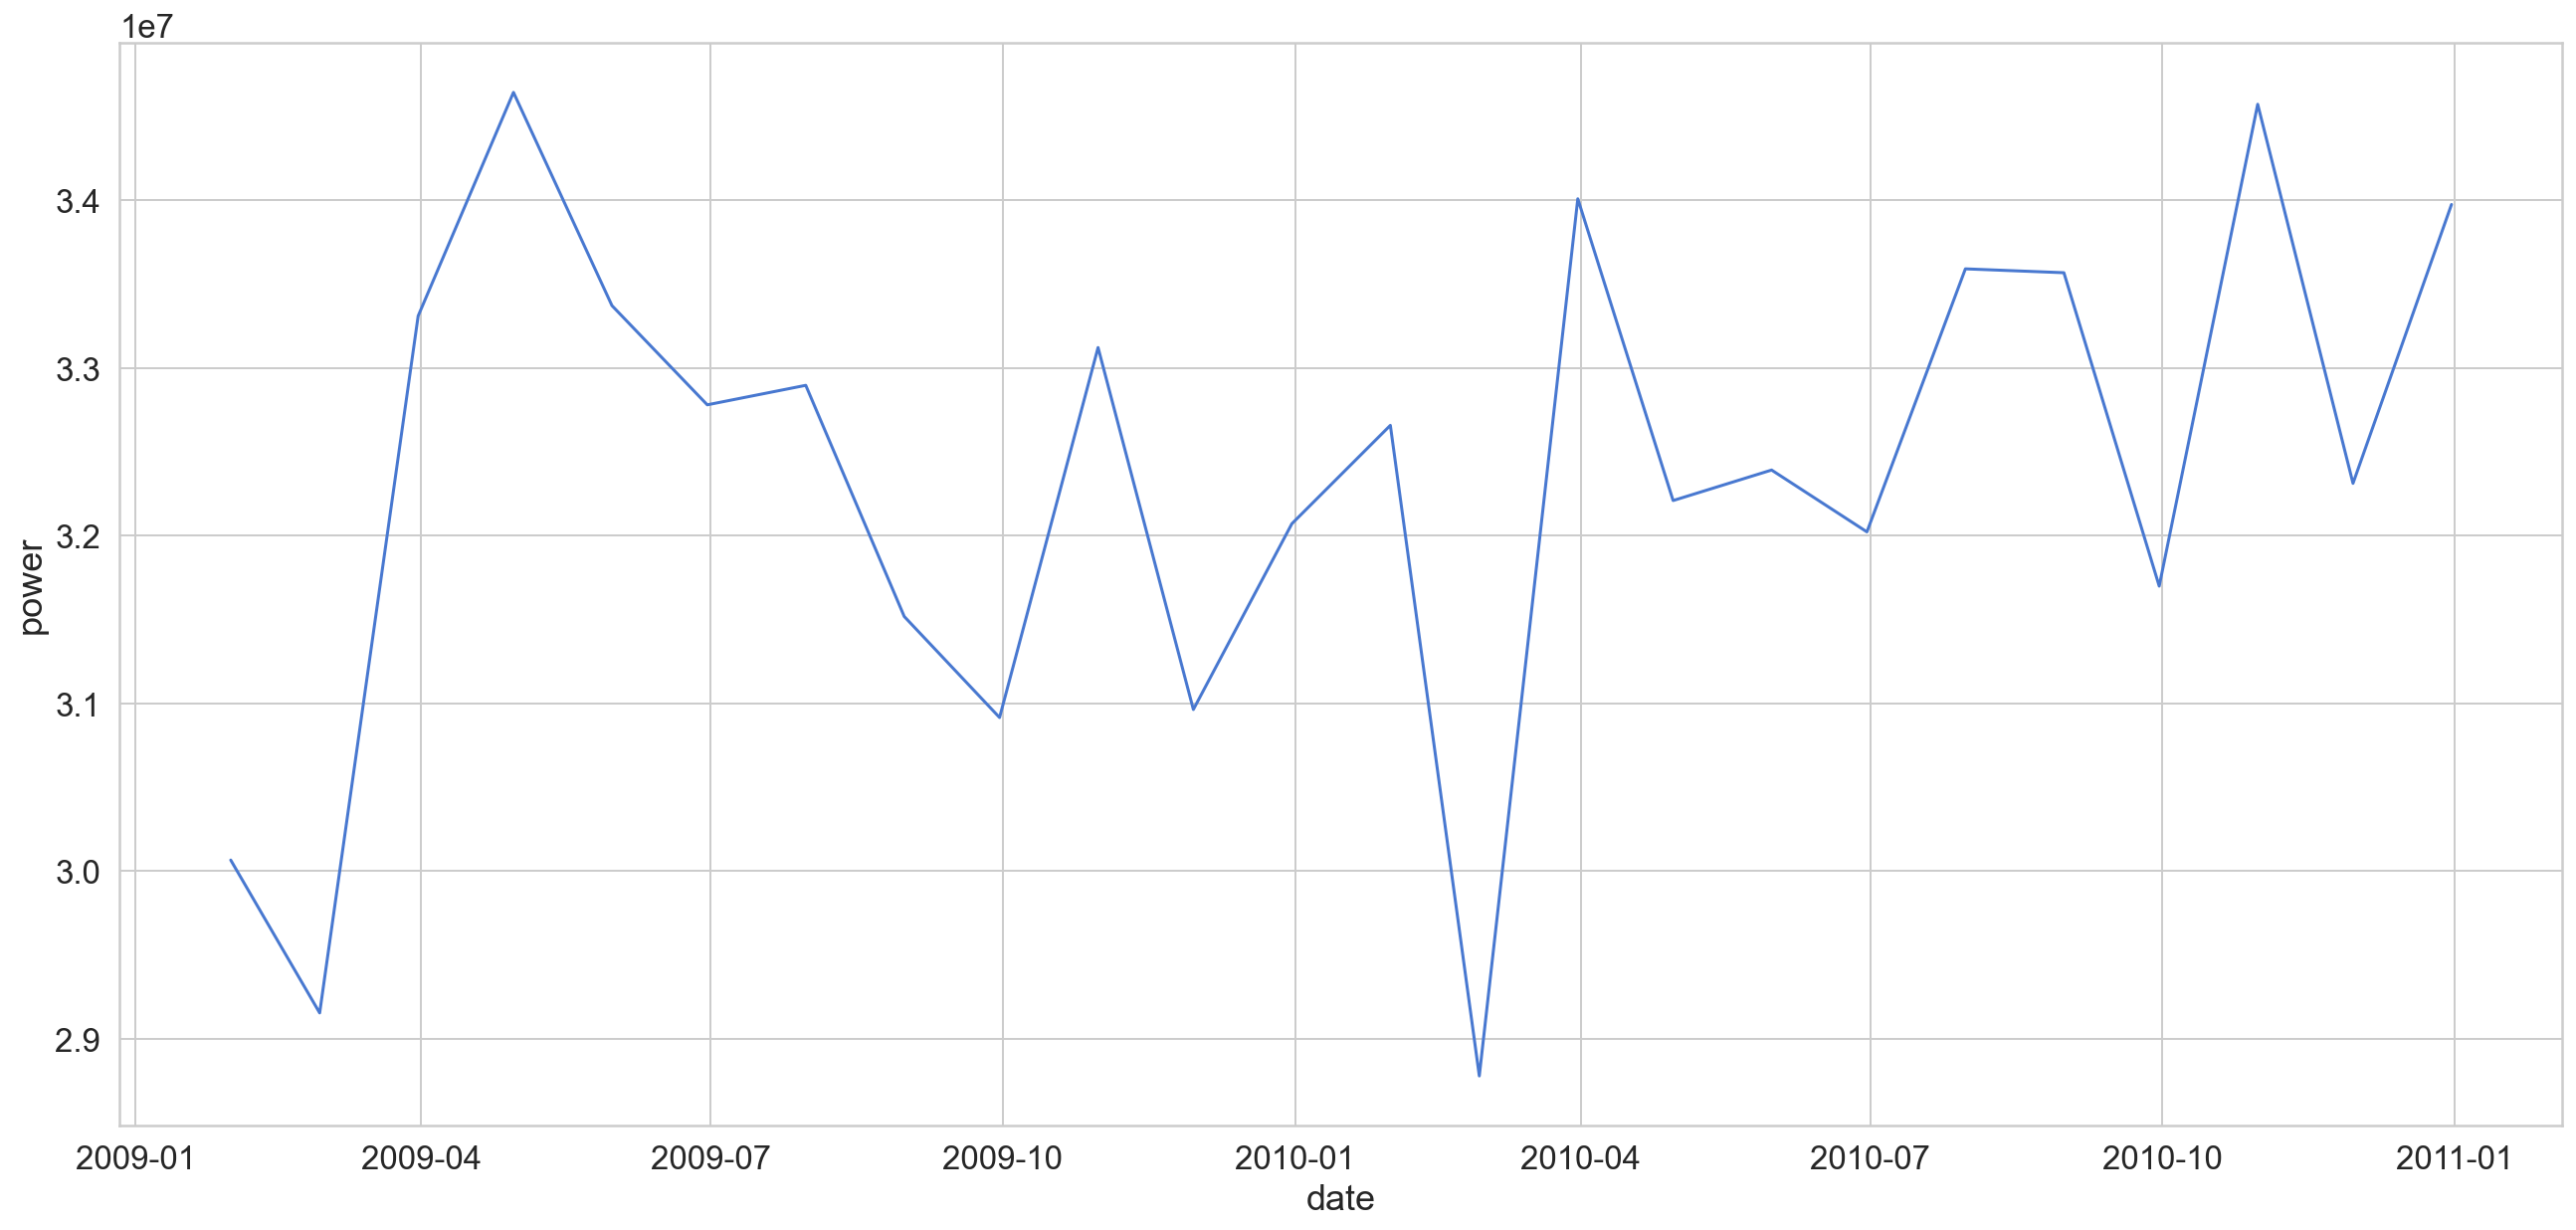

In [143]:
df_by_month = df.resample('M').sum()
sns.lineplot(x=df_by_month.index, y="power", data=df_by_month);


- plotting the data considering the average active power values for days of the week and days of month

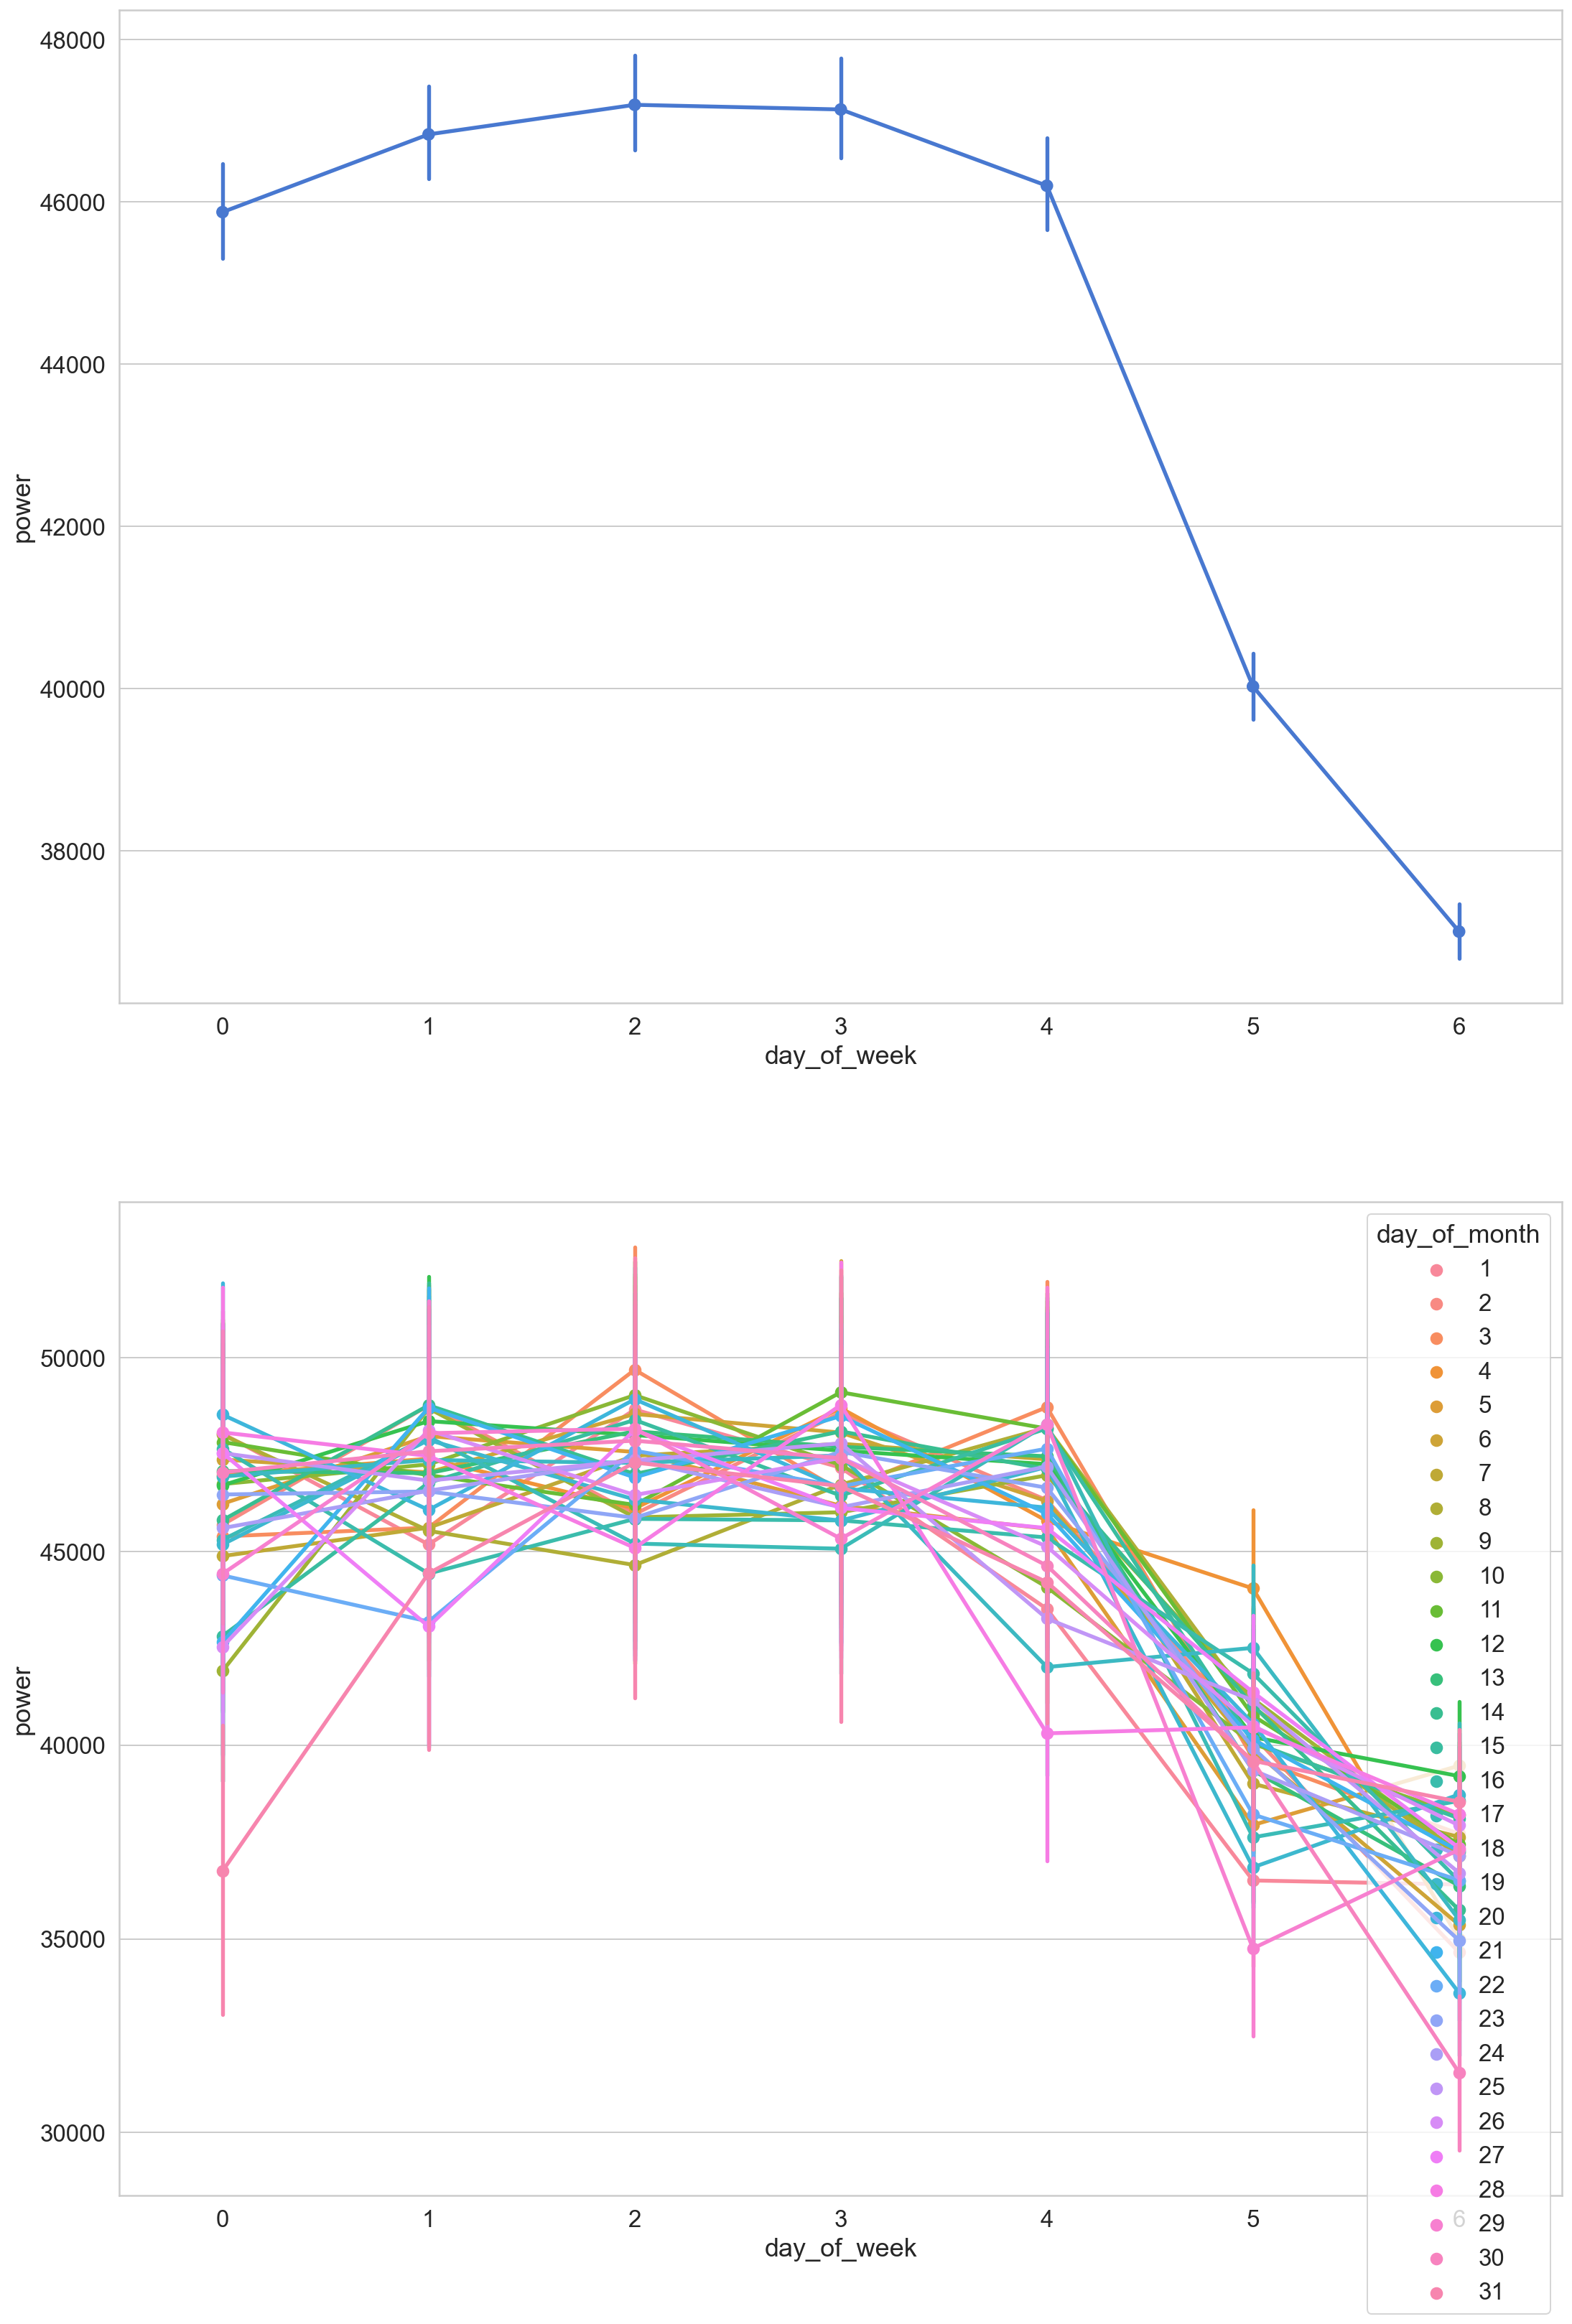

In [144]:
fig,(ax1, ax2)= plt.subplots(nrows=2)
fig.set_size_inches(18, 28)

sns.pointplot(data=df, x='day_of_week', y='power', ax=ax1)
sns.pointplot(data=df, x='day_of_week', y='power', hue='day_of_month', ax=ax2);


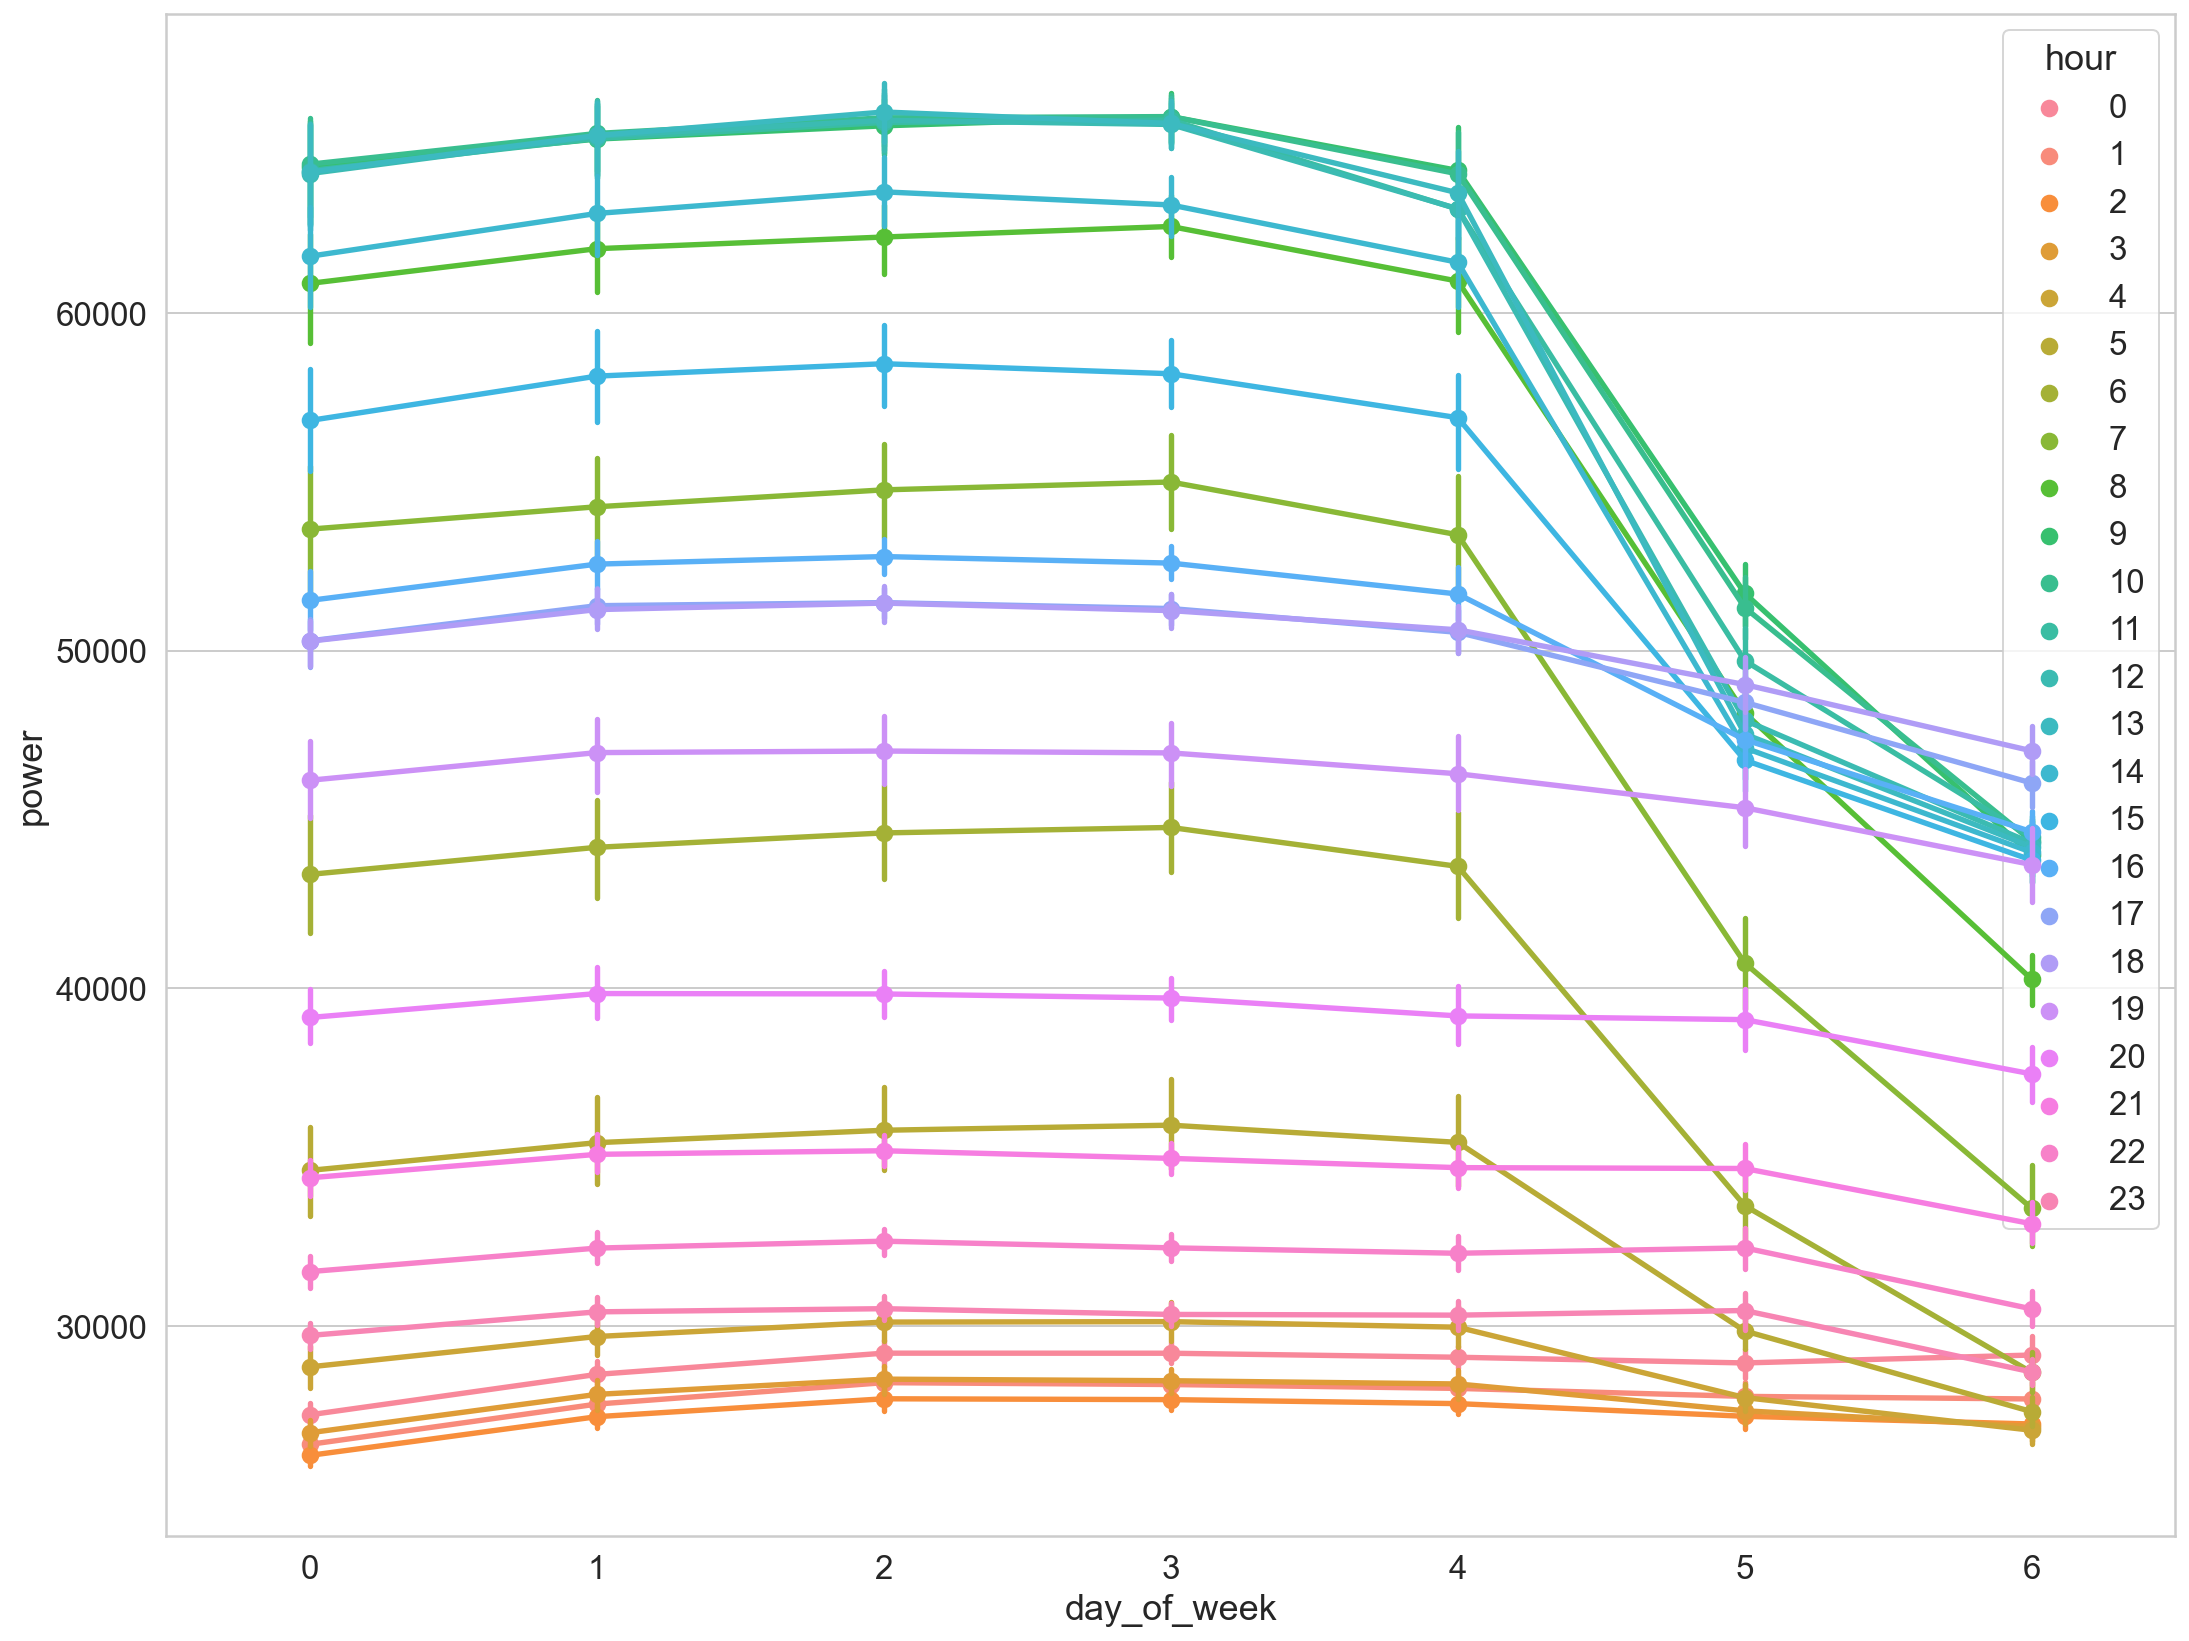

In [145]:
fig,(ax1)= plt.subplots(nrows=1)
fig.set_size_inches(18, 14)

sns.pointplot(data=df, x='day_of_week', y='power',hue='hour', ax=ax1);

# splitting the data into train and test 

In [146]:
train_size = int(len(df) * (1- test_ratio))
test_size = len(df) - train_size
train, test = df.iloc[0:train_size], df.iloc[train_size:]
print(len(train), len(test))


14015 3504


# feature selection 
- experiments have shown that only the day of week is important for the prediction (you can make your own feature selection and share the results with me)

- having other indexes cause overfitting

In [147]:
df.drop([ 'day_of_month', 'month', 'hour'], axis=1, inplace=True)

# Preprocessing

In [148]:
#f_transformer = RobustScaler()
cnt_transformer = RobustScaler()

#f_transformer = f_transformer.fit(train[f_columns].to_numpy())
cnt_transformer = cnt_transformer.fit(train[['power']])

#train.loc[:, f_columns] = f_transformer.transform(train[f_columns].to_numpy())
train['power'] = cnt_transformer.transform(train[['power']])

#test.loc[:, f_columns] = f_transformer.transform(test[f_columns].to_numpy())
test['power'] = cnt_transformer.transform(test[['power']])

train.head

<bound method NDFrame.head of                         power  hour  day_of_month  day_of_week  month
date                                                                 
2009-01-01 00:00:00 -0.533970     0             1            3      1
2009-01-01 01:00:00 -0.583767     1             1            3      1
2009-01-01 02:00:00 -0.627944     2             1            3      1
2009-01-01 03:00:00 -0.630217     3             1            3      1
2009-01-01 04:00:00 -0.642656     4             1            3      1
...                       ...   ...           ...          ...    ...
2010-08-07 18:00:00  0.243904    18             7            5      8
2010-08-07 19:00:00 -0.205430    19             7            5      8
2010-08-07 20:00:00 -0.345731    20             7            5      8
2010-08-07 21:00:00 -0.443260    21             7            5      8
2010-08-07 22:00:00 -0.502025    22             7            5      8

[14015 rows x 5 columns]>

# Creating the dataset for model based on autoregressive model

In [149]:
# one hour output
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)         
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)


# reshape to [samples, time_steps, n_features]

X_train, y_train = create_dataset(train, train.power, time_steps)
X_test, y_test = create_dataset(test, test.power, time_steps)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
X_test.shape


(14001, 14, 5) (14001,)
(3490, 14, 5) (3490,)


(3490, 14, 5)

# Creating the LSTM model 

In [150]:
model = keras.Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(LSTM(units=128))

model.add(keras.layers.Dropout(rate=Dropout_rate))
model.add(keras.layers.Dense(units=1,activation="linear"))
keras.backend.set_epsilon(1)
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mape'])


# training the model

Epoch 1/50
394/394 [==============================] - 18s 35ms/step - loss: 0.1487 - mape: 28.1104 - val_loss: 0.0360 - val_mape: 15.2771
Epoch 2/50
394/394 [==============================] - 16s 41ms/step - loss: 0.0447 - mape: 15.9911 - val_loss: 0.0214 - val_mape: 11.4557
Epoch 3/50
394/394 [==============================] - 17s 43ms/step - loss: 0.0294 - mape: 12.8968 - val_loss: 0.0185 - val_mape: 10.6322
Epoch 4/50
394/394 [==============================] - 16s 41ms/step - loss: 0.0223 - mape: 11.2707 - val_loss: 0.0197 - val_mape: 10.8166
Epoch 5/50
394/394 [==============================] - 18s 46ms/step - loss: 0.0181 - mape: 10.2238 - val_loss: 0.0199 - val_mape: 10.7858
Epoch 6/50
394/394 [==============================] - 17s 43ms/step - loss: 0.0146 - mape: 9.1961 - val_loss: 0.0182 - val_mape: 10.3581
Epoch 7/50
394/394 [==============================] - 20s 51ms/step - loss: 0.0113 - mape: 8.0869 - val_loss: 0.0162 - val_mape: 9.9146
Epoch 8/50
394/394 [=================

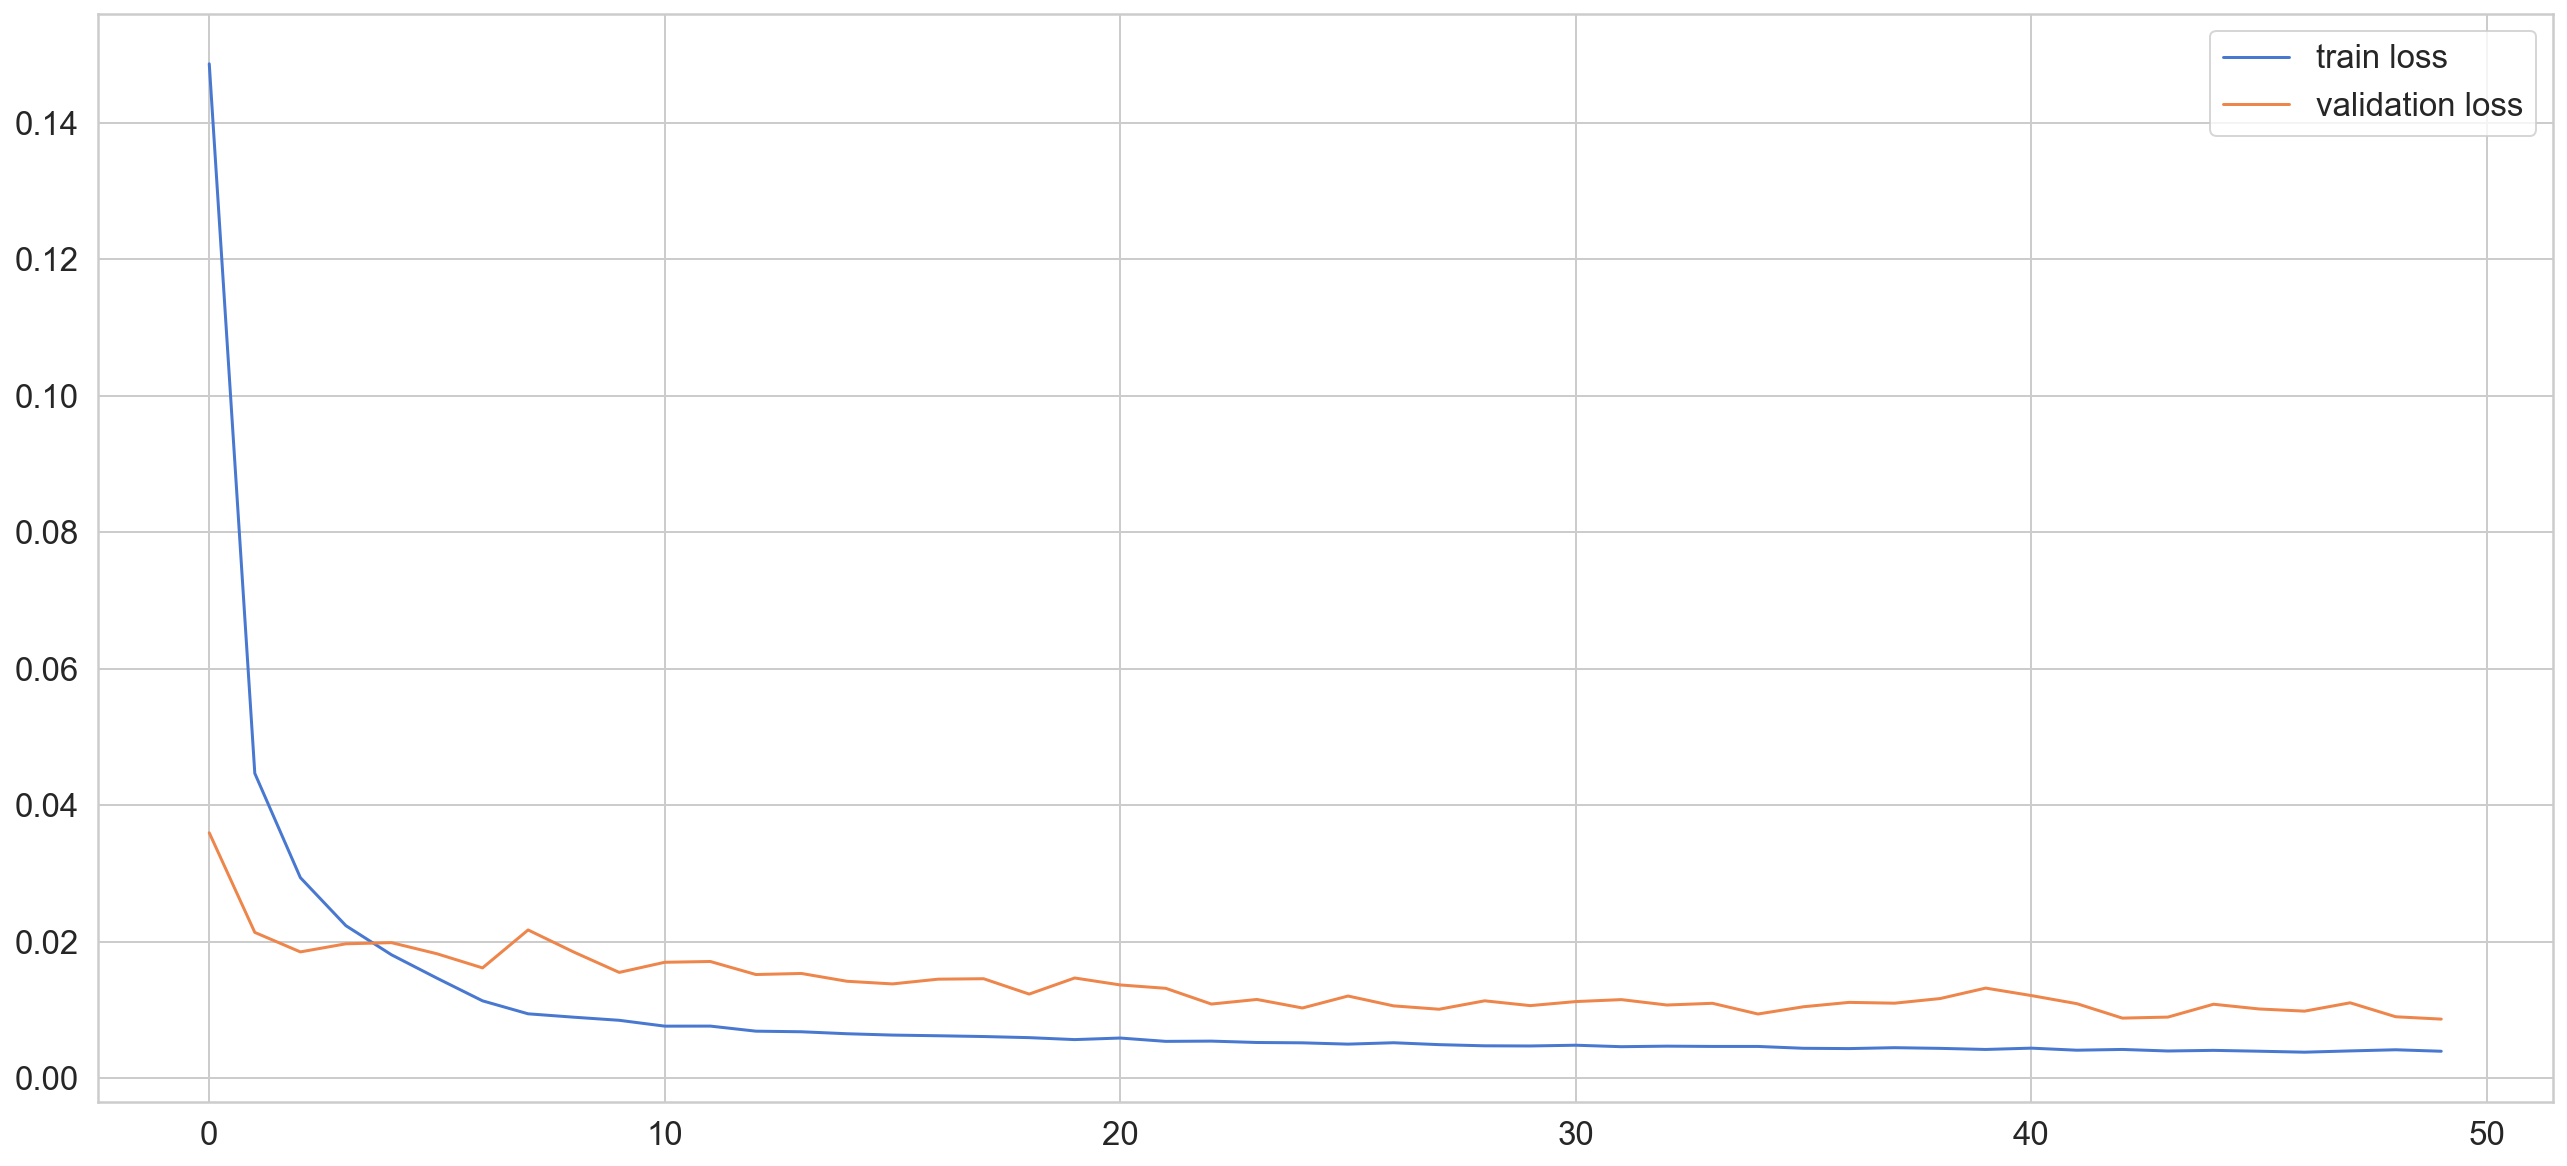

In [151]:
history = model.fit(
    X_train, y_train, 
    epochs=no_epochs, 
    verbose=1,
    batch_size=batch_size, 
    validation_split=0.1,
    shuffle=False
)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend();


- predict test data

In [152]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

- reverse the data back to real values using inverse transform

In [153]:
y_train_inv = cnt_transformer.inverse_transform(y_train.reshape(1, -1))
y_test_inv = cnt_transformer.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = cnt_transformer.inverse_transform(y_pred)
y_pred_train_inv = cnt_transformer.inverse_transform(y_pred_train)

- plot regression diagram for some random data points

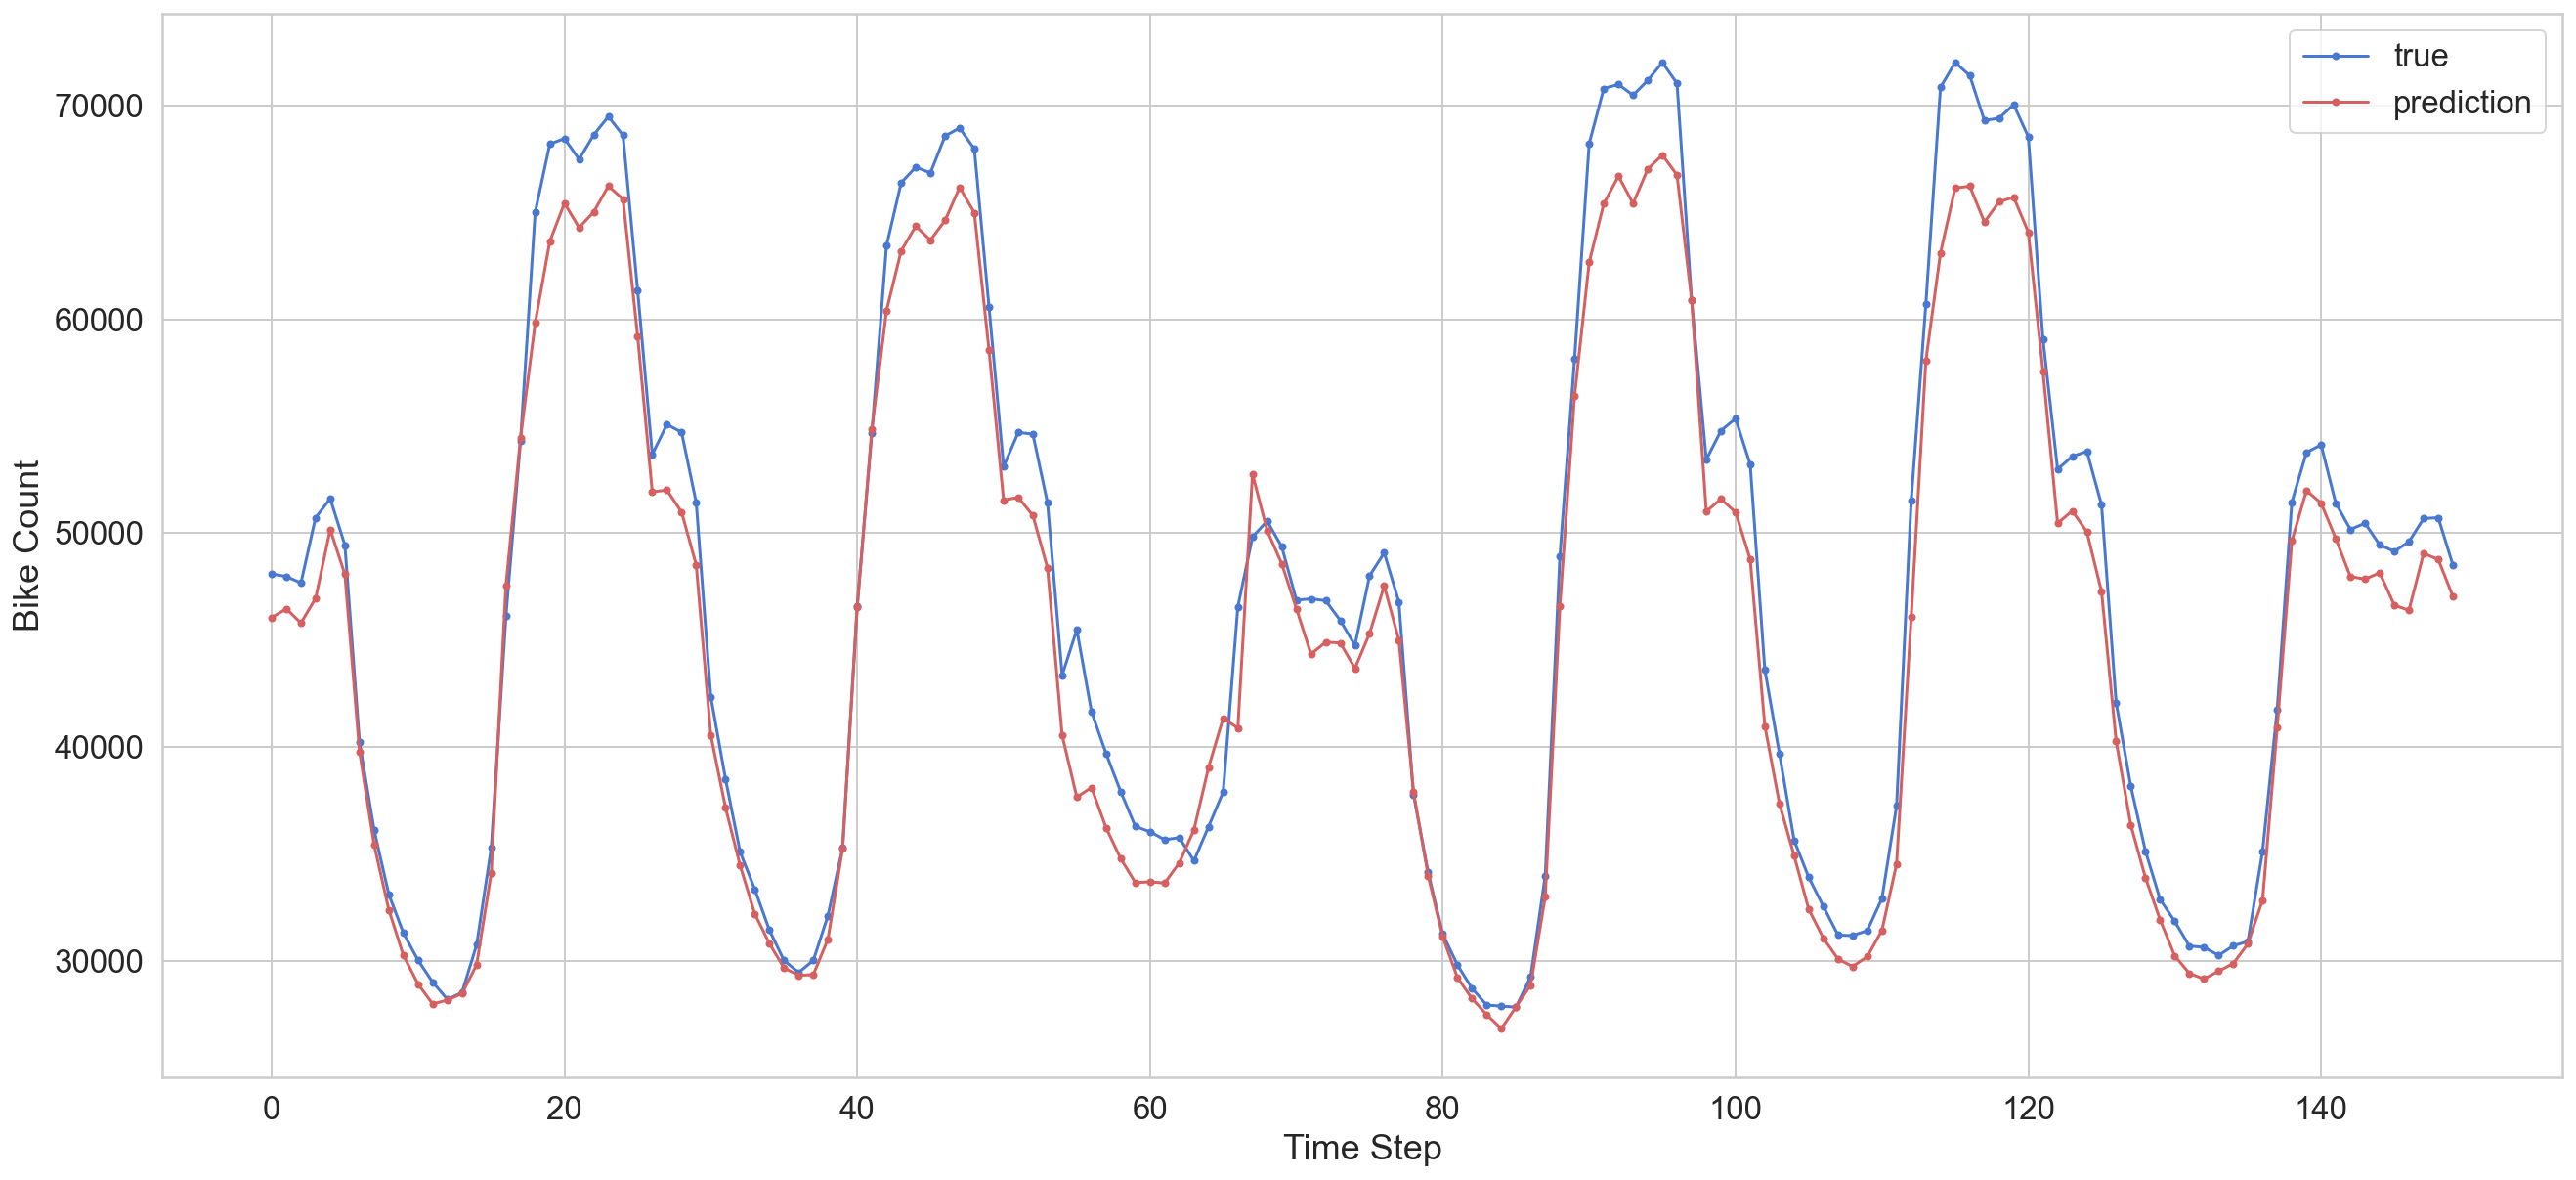

In [154]:
plt.plot(y_test_inv.flatten()[0:150], marker='.', label="true")
plt.plot(y_pred_inv.flatten()[0:150], 'r', marker='.', label="prediction")
plt.ylabel('Bike Count')
plt.xlabel('Time Step')
plt.legend()
plt.show();


- comparing Mean absolute error of validation and trian data during training

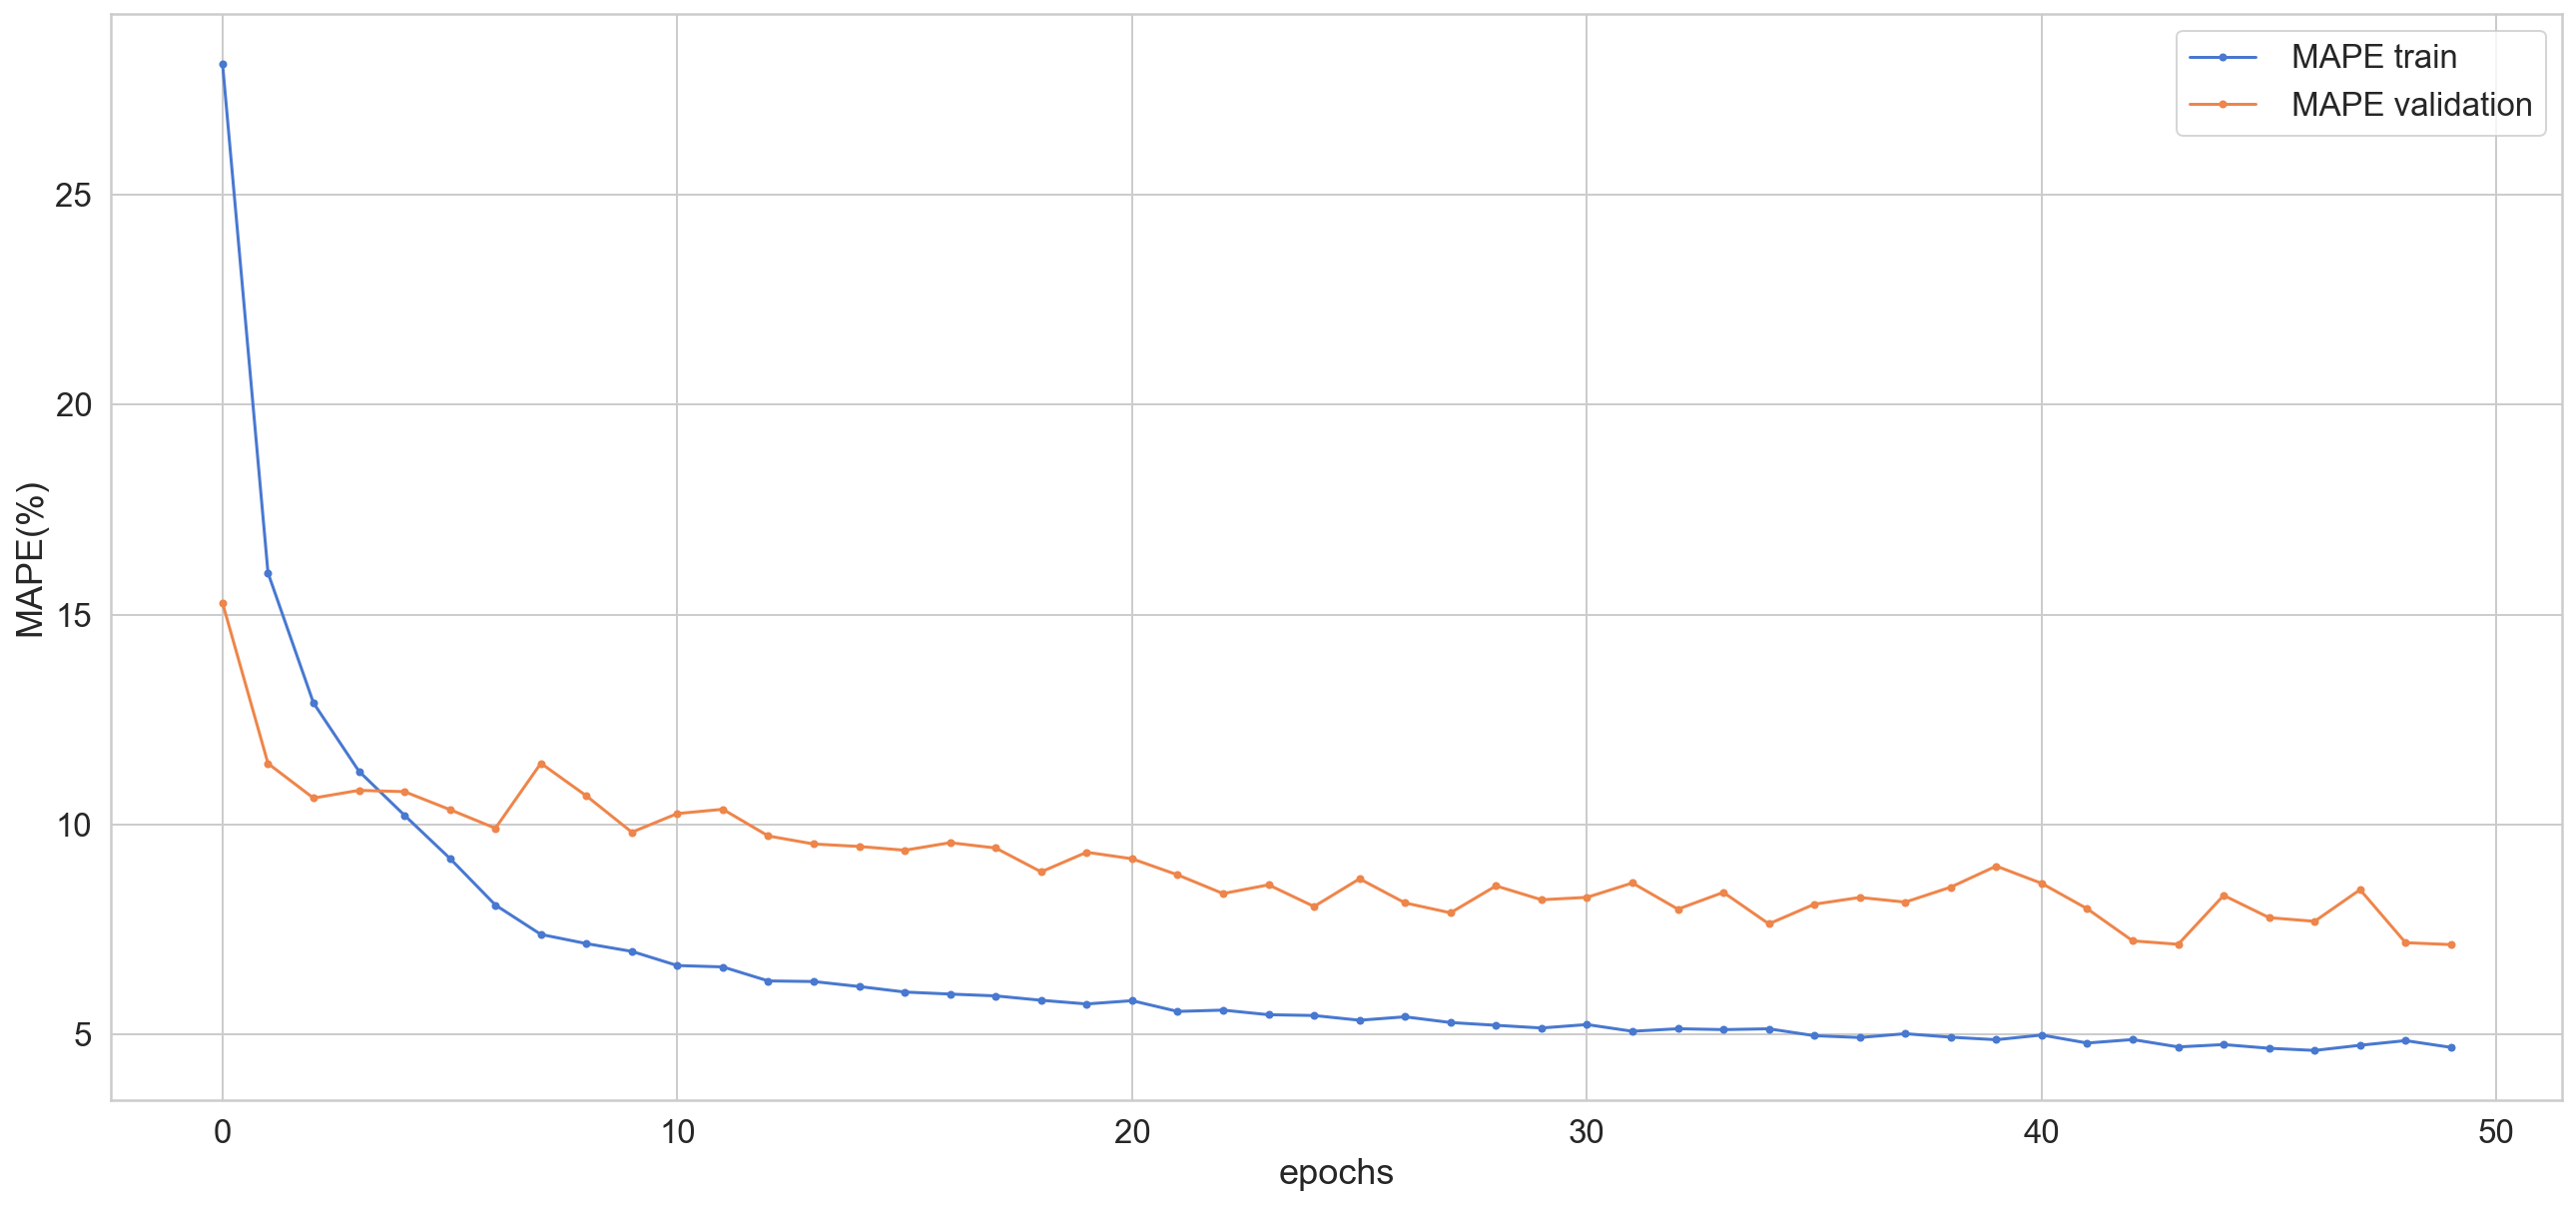

In [155]:
plt.plot(history.history['mape'], marker='.', label=" MAPE train")
plt.plot(history.history['val_mape'], marker='.', label=" MAPE validation")

plt.xlabel('epochs')
plt.ylabel('MAPE(%)')
plt.legend()
plt.show();